# Group Notebook 2 — Cross-Member Comparison and Business Recommendations

**Module:** COM3032 / COMM074 — Business Analytics with Data Visualisation
**Group:** 12 — Credit Card Fraud Detection (Pozzolo Kaggle dataset)

This notebook aggregates every group member's individual model results into a single comparison table and set of figures. It is the integration point between the six individual notebooks (one per member) and Section 4 (Performance Evaluation cross-comparison) plus Section 5 (Recommendations) of the group report.

**Inputs.** Any `outputs/results/results_*.csv` files in the project. Each individual member writes to this directory at the end of their notebook using `src.evaluation.evaluate_model_full`, which guarantees the locked group schema:

```
member, model, split, imbalance_strategy, threshold,
pr_auc, roc_auc, recall_at_90p, f1, precision, recall, accuracy,
tp, fp, fn, tn
```

**Legacy CSVs.** Earlier results CSVs (e.g. Enisa's initial submission) used a 7-column schema. This notebook ingests them too: missing columns are padded with `NaN` so the comparison still runs. The marker can see which rows are from the locked schema and which are partial.

**Outputs.**
- `outputs/results/group_comparison.csv` — aggregated comparison table across all members
- `outputs/figures/group_pr_auc_comparison.png` — test-set PR-AUC bar chart
- `outputs/figures/group_recall_at_90p_comparison.png` — test-set recall-at-90%-precision bar chart
- `outputs/figures/group_precision_recall_scatter.png` — test-set precision vs recall trade-off

## 1. Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src" / "config.py").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import OUTPUT_FIGURES_DIR, OUTPUT_RESULTS_DIR

OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

LOCKED_SCHEMA = [
    "member", "model", "split", "imbalance_strategy", "threshold",
    "pr_auc", "roc_auc", "mcc", "recall_at_90p",
    "f1", "precision", "recall", "fpr", "accuracy",
    "tp", "fp", "fn", "tn",
]

print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir:  {OUTPUT_RESULTS_DIR}")
print(f"Figures dir:  {OUTPUT_FIGURES_DIR}")


Project root: /Users/shamzzzh/Desktop/COM3032
Results dir:  /Users/shamzzzh/Desktop/COM3032/outputs/results
Figures dir:  /Users/shamzzzh/Desktop/COM3032/outputs/figures


## 2. Load every `results_*.csv` and normalise schema

Each member's CSV is loaded in turn. Missing locked-schema columns are padded with `NaN`. A `__source_file` column records the origin so the marker can trace any row back to its author.

In [2]:
result_files = sorted(OUTPUT_RESULTS_DIR.glob("results_*.csv"))
print(f"Found {len(result_files)} member result files:")
for f in result_files:
    print(f"  - {f.name}")

if not result_files:
    print("\nNo member result files found. Each member should write outputs/results/results_<name>.csv at the end of their individual notebook.")

frames = []
for f in result_files:
    df = pd.read_csv(f)
    for col in LOCKED_SCHEMA:
        if col not in df.columns:
            df[col] = np.nan
    df["__source_file"] = f.name
    frames.append(df[LOCKED_SCHEMA + ["__source_file"]])

if frames:
    all_results = pd.concat(frames, ignore_index=True)
else:
    all_results = pd.DataFrame(columns=LOCKED_SCHEMA + ["__source_file"])

print(f"\nTotal rows aggregated: {len(all_results)}")
print(f"Distinct members: {sorted(all_results['member'].dropna().unique().tolist())}")
print(f"Distinct models: {sorted(all_results['model'].dropna().unique().tolist())}")


Found 2 member result files:
  - results_enisa.csv
  - results_shom.csv

Total rows aggregated: 8
Distinct members: ['Enisa', 'Shom']
Distinct models: ['KNN (k=21)', 'LogReg L1 (C=0.5)', 'LogReg L2 C=0.1 (baseline)', 'LogReg L2 C=0.1 (tuned)', 'XGBoost (baseline)', 'XGBoost (tuned)']


## 3. Test-set comparison table

We sort by PR-AUC descending — our locked primary metric. Rows with no `split` value (legacy schemas) are kept but appear at the bottom.

In [3]:
display_cols = [
    "member", "model", "imbalance_strategy",
    "pr_auc", "roc_auc", "mcc", "recall_at_90p",
    "f1", "precision", "recall", "fpr", "threshold",
]

test_results = all_results[all_results["split"].fillna("test").eq("test")].copy()
test_results = test_results.sort_values("pr_auc", ascending=False, na_position="last")
if len(test_results) > 0:
    print("Test-set results (sorted by PR-AUC desc):")
    print(test_results[display_cols].to_string(index=False))
else:
    print("No test-set rows yet. Members should run their individual notebooks and save results to outputs/results/.")


Test-set results (sorted by PR-AUC desc):
member                   model    imbalance_strategy   pr_auc  roc_auc      mcc  recall_at_90p      f1  precision   recall      fpr  threshold
  Shom         XGBoost (tuned)      scale_pos_weight 0.820261 0.981342 0.848624       0.760563 0.84375   0.947368 0.760563 0.000071   0.836150
 Enisa              KNN (k=21)                   NaN 0.800500 0.932000      NaN            NaN     NaN   1.000000 0.590000      NaN   0.761900
 Enisa       LogReg L1 (C=0.5)                   NaN 0.702600 0.955700      NaN            NaN     NaN   0.820000 0.660000      NaN   0.500000
  Shom LogReg L2 C=0.1 (tuned) class_weight_balanced 0.681525 0.972802 0.803139       0.000000 0.80292   0.833333 0.774648 0.000259   0.999999


## 4. PR-AUC bar chart (test set)

The primary metric for the rubric. Higher is better.

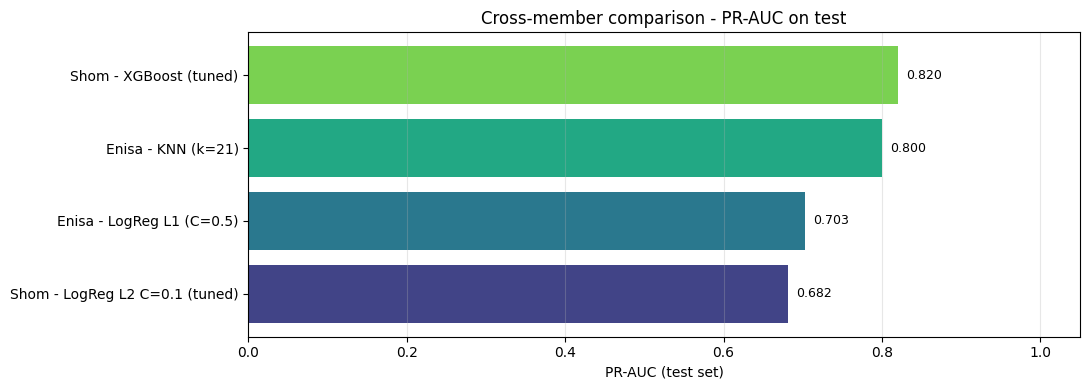

In [4]:
plot_df = test_results.dropna(subset=["pr_auc"]).copy()

if len(plot_df) > 0:
    plot_df = plot_df.sort_values("pr_auc", ascending=True)
    labels = plot_df.apply(lambda r: f"{r['member']} - {r['model']}", axis=1)
    colors = sns.color_palette("viridis", len(plot_df))

    fig, ax = plt.subplots(figsize=(11, max(4, 0.4 * len(plot_df) + 2)))
    bars = ax.barh(labels, plot_df["pr_auc"], color=colors)
    ax.set_xlabel("PR-AUC (test set)")
    ax.set_xlim(0, 1.05)
    ax.set_title("Cross-member comparison - PR-AUC on test")
    for bar, val in zip(bars, plot_df["pr_auc"]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUTPUT_FIGURES_DIR / "group_pr_auc_comparison.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("No PR-AUC values to plot yet.")


## 5. Matthews Correlation Coefficient (test set)

MCC is the module's recommended single-measure metric for unbalanced binary classification. It returns values in `[-1, 1]`: 0 = random, 1 = perfect, -1 = perfectly wrong. Unlike accuracy and F1, MCC is symmetric across classes and is robust to extreme class imbalance — which is why the lecture notes describe it as "a reasonable single measure even on unbalanced datasets".

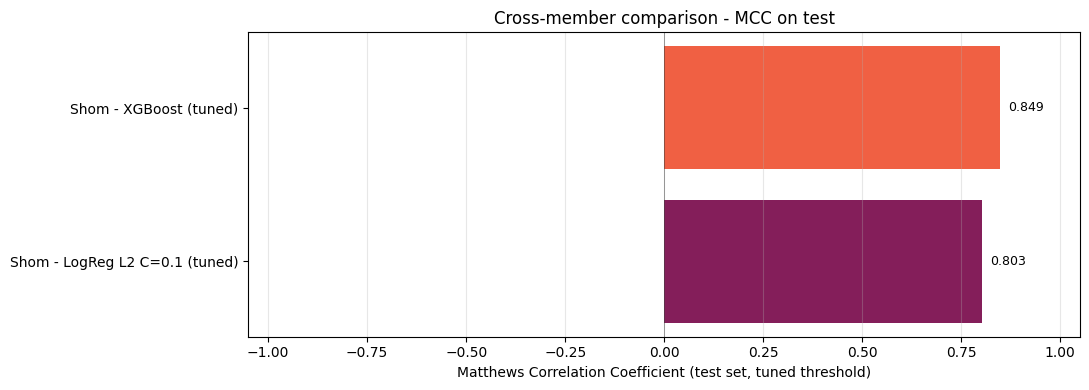

In [5]:
mcc_df = test_results.dropna(subset=["mcc"]).copy()

if len(mcc_df) > 0:
    mcc_df = mcc_df.sort_values("mcc", ascending=True)
    labels = mcc_df.apply(lambda r: f"{r['member']} - {r['model']}", axis=1)
    fig, ax = plt.subplots(figsize=(11, max(4, 0.4 * len(mcc_df) + 2)))
    colors = sns.color_palette("rocket", len(mcc_df))
    bars = ax.barh(labels, mcc_df["mcc"], color=colors)
    ax.set_xlabel("Matthews Correlation Coefficient (test set, tuned threshold)")
    ax.set_xlim(-1.05, 1.05)
    ax.axvline(0, color="black", linewidth=0.5, alpha=0.5)
    ax.set_title("Cross-member comparison - MCC on test")
    for bar, val in zip(bars, mcc_df["mcc"]):
        ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUTPUT_FIGURES_DIR / "group_mcc_comparison.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("No MCC values to plot yet (legacy results CSVs lack the column).")


## 6. Recall at 90% precision (test set)

Our locked secondary metric. Some models may not reach 90% precision at any threshold — those are excluded from the chart and flagged below.

Models that did NOT reach 90% precision on test (recall_at_90p = 0):
member                   model    imbalance_strategy
  Shom LogReg L2 C=0.1 (tuned) class_weight_balanced



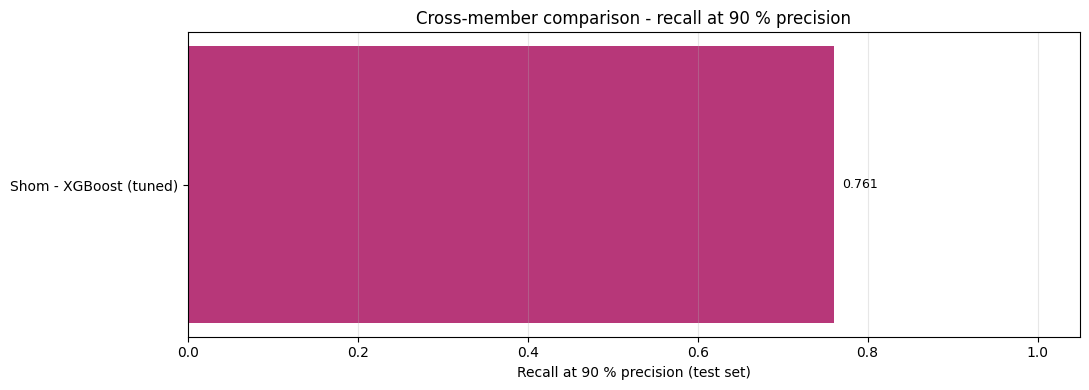

In [6]:
r90_df = test_results.copy()
r90_df = r90_df.dropna(subset=["recall_at_90p"])

unable = r90_df[r90_df["recall_at_90p"] <= 0.0]
able = r90_df[r90_df["recall_at_90p"] > 0.0].sort_values("recall_at_90p", ascending=True)

if len(unable) > 0:
    print("Models that did NOT reach 90% precision on test (recall_at_90p = 0):")
    print(unable[["member", "model", "imbalance_strategy"]].to_string(index=False))
    print()

if len(able) > 0:
    labels = able.apply(lambda r: f"{r['member']} - {r['model']}", axis=1)
    fig, ax = plt.subplots(figsize=(11, max(4, 0.4 * len(able) + 2)))
    colors = sns.color_palette("magma", len(able))
    bars = ax.barh(labels, able["recall_at_90p"], color=colors)
    ax.set_xlabel("Recall at 90 % precision (test set)")
    ax.set_xlim(0, 1.05)
    ax.set_title("Cross-member comparison - recall at 90 % precision")
    for bar, val in zip(bars, able["recall_at_90p"]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUTPUT_FIGURES_DIR / "group_recall_at_90p_comparison.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("No models reached 90 % precision on test yet.")


## 7. Precision vs recall trade-off (test set)

A scatter of each model's tuned-threshold operating point. The top-right corner (high precision AND high recall) is the goal; the trade-off between them is what the bank's policy team needs to weigh.

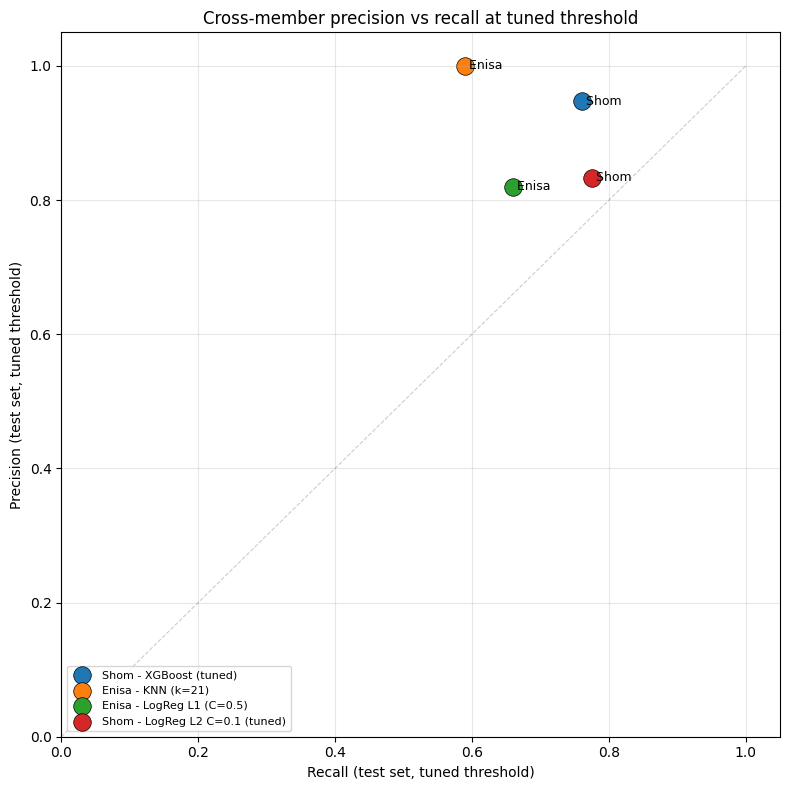

In [7]:
scatter_df = test_results.dropna(subset=["precision", "recall"]).copy()

if len(scatter_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 8))
    palette = sns.color_palette("tab10", len(scatter_df))
    for (_, row), col in zip(scatter_df.iterrows(), palette):
        ax.scatter(row["recall"], row["precision"], s=160, color=col,
                   edgecolors="black", linewidths=0.5,
                   label=f"{row['member']} - {row['model']}")
        ax.annotate(f" {row['member']}",
                    (row["recall"], row["precision"]),
                    fontsize=9, va="center")
    ax.set_xlabel("Recall (test set, tuned threshold)")
    ax.set_ylabel("Precision (test set, tuned threshold)")
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_title("Cross-member precision vs recall at tuned threshold")
    ax.grid(alpha=0.3)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.2, linewidth=0.8)
    ax.legend(loc="lower left", fontsize=8)
    fig.tight_layout()
    fig.savefig(OUTPUT_FIGURES_DIR / "group_precision_recall_scatter.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("No (precision, recall) pairs to plot yet.")


## 8. Confusion-matrix counts (test set, tuned thresholds)

For each model at its tuned threshold, the test-set confusion matrix in raw counts. Lets the marker see exactly how many fraud cases each member caught and how many false flags each generated, at one glance.

In [8]:
cm_cols = ["member", "model", "imbalance_strategy", "threshold",
           "tp", "fp", "fn", "tn"]
cm_df = test_results[cm_cols].dropna(subset=["tp", "fp", "fn", "tn"]).copy()
if len(cm_df) > 0:
    cm_df[["tp", "fp", "fn", "tn"]] = cm_df[["tp", "fp", "fn", "tn"]].astype(int)
    print("Confusion-matrix counts at tuned threshold (test set):")
    print(cm_df.to_string(index=False))
else:
    print("No confusion-matrix counts available yet (legacy CSVs lack tp/fp/fn/tn).")


Confusion-matrix counts at tuned threshold (test set):
member                   model    imbalance_strategy  threshold  tp  fp  fn    tn
  Shom         XGBoost (tuned)      scale_pos_weight   0.836150  54   3  17 42485
  Shom LogReg L2 C=0.1 (tuned) class_weight_balanced   0.999999  55  11  16 42477


## 9. Aggregated comparison written to disk

The full aggregated table goes to `outputs/results/group_comparison.csv` for any downstream analysis.

In [9]:
output_path = OUTPUT_RESULTS_DIR / "group_comparison.csv"
all_results.to_csv(output_path, index=False)
print(f"Aggregated comparison written: {output_path}")

if len(test_results.dropna(subset=["pr_auc"])) > 0:
    best = test_results.dropna(subset=["pr_auc"]).iloc[0]
    print(f"\nLeading model by test PR-AUC: {best['member']} - {best['model']} "
          f"(PR-AUC = {best['pr_auc']:.4f}, "
          f"recall_at_90p = {best['recall_at_90p'] if pd.notna(best['recall_at_90p']) else 'n/a'}, "
          f"F1 = {best['f1'] if pd.notna(best['f1']) else 'n/a'})")


Aggregated comparison written: /Users/shamzzzh/Desktop/COM3032/outputs/results/group_comparison.csv

Leading model by test PR-AUC: Shom - XGBoost (tuned) (PR-AUC = 0.8203, recall_at_90p = 0.7605633802816901, F1 = 0.84375)


## 10. Notes for §4 cross-comparison narrative

The §4 cross-comparison paragraph (each individual member's, plus the group-level summary) is anchored on **mechanism** as well as numbers:

- **Tree-based families** (XGBoost, Random Forest) — gradient boosting versus bagging, bias-variance trade-off.
- **Margin-based** (SVM RBF) — kernel-induced non-linearity, no native probability output.
- **Instance-based** (KNN) — curse of dimensionality, scaling sensitivity, well-documented SMOTE interaction.
- **Generative** (QDA) — Gaussian assumption versus the binary engineered features (`is_night`, `is_business_hours`, `is_small_amount`, `is_round_amount`).
- **Neural network** (MLP) — composed non-linearity, requires KernelSHAP rather than TreeSHAP.

The aim of §4 is to explain *why* the leading model leads and *why* the trailing model trails, not just to rank them by PR-AUC.

The §5 recommendations (tiered review queues, time-of-day rules, amount-band threshold calibration) are anchored on the **engineered features** the SHAP analysis in each individual notebook highlights — `hour_of_day`, `is_night`, `amount_band_encoded`, `log_amount`. The cross-member SHAP findings converge on those features as the operationally actionable signal, independent of model family.